# Análise de Cancelamento de Clientes — Seguradora Atlas

## Sobre o projeto

Este projeto tem como objetivo realizar uma análise exploratória dos dados de clientes da Seguradora Atlas, buscando identificar padrões relacionados ao cancelamento de seguros.

A análise foi desenvolvida como projeto de estudo, utilizando um conjunto de dados sintético para praticar técnicas de limpeza, tratamento, exploração e visualização de dados com Python.

## Objetivo

Investigar os principais fatores associados aos cancelamentos e identificar padrões que possam auxiliar na formulação de hipóteses e estratégias de retenção de clientes.


In [6]:
#importação
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
tabela = pd.read_excel("C:/Users/vivia/OneDrive/Desktop/Seguradora Atlas/Base_Seguros.xlsx")
tabela

,Cliente_ID,Data_Contratacao,Idade,Genero,Estado_Civil,Profissao,Renda_Mensal,Score_Credito,Regiao,Corretor,Tipo_Seguro,Plano,Valor_Mensal,Sinistros,Atrasos_Pagamento,Usa_App,Satisfacao,Cancelou,Motivo_Cancelamento
0,1,30-Sep-2022,75,Masculino,Divorciado,Programador,9249.0,617.0,Nordeste,Eduardo,Residencial,Anual,"R$ 174,00",3,4,nao,6.0,Não,NaN
1,2,2024-05-26,53,Feminino,Casado,Enfermeiro,12861.0,749.0,sudeste,Bruno,Auto,Mensal,485,1,6,nao,10.0,Não,NaN
2,3,30/03/2024,63,F,Divorciado,Vendedor,10388.0,940.0,Centro-Oeste,Bruno,Auto,Mensal,542,4,3,Sim,5.0,Sim,Preço
3,4,16-Apr-2023,35,Masculino,solteiro,Vendedor,15863.0,455.0,SUDESTE,Daniela,Residencial,Mensal,44,3,2,Sim,10.0,Não,NaN
4,5,22/02/2022,28,Masculino,solteiro,Engenheiro,6487.0,885.0,Centro-Oeste,Bruno,Residencial,Anual,61,3,2,Sim,8.0,Não,Preço
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4115,1010,24/10/2024,21,Feminino,Casado,Programador,5930.0,NaN,Nordeste,Eduardo,Auto,Anual,533,3,1,nao,1.0,Não,NaN
4116,695,05/11/2023,75,M,solteiro,Autônomo,17396.0,914.0,NORTE,Bruno,Auto,Anual,570,0,1,Sim,8.0,Não,NaN
4117,474,19/09/2021,56,Feminino,Solteiro,Vendedor,3203.0,667.0,Centro-Oeste,Bruno,Auto,Anual,526,4,2,sim,2.0,Não,NaN
4118,1812,12-Sep-2025,27,Fem,solteiro,Enfermeiro,2016.0,428.0,Sul,Ana,Saúde,Anual,659,1,3,Não,4.0,Não,NaN


Conhecendo os dados

In [8]:
tabela.head()

,Cliente_ID,Data_Contratacao,Idade,Genero,Estado_Civil,Profissao,Renda_Mensal,Score_Credito,Regiao,Corretor,Tipo_Seguro,Plano,Valor_Mensal,Sinistros,Atrasos_Pagamento,Usa_App,Satisfacao,Cancelou,Motivo_Cancelamento
0,1,30-Sep-2022,75,Masculino,Divorciado,Programador,9249.0,617.0,Nordeste,Eduardo,Residencial,Anual,"R$ 174,00",3,4,nao,6.0,Não,NaN
1,2,2024-05-26,53,Feminino,Casado,Enfermeiro,12861.0,749.0,sudeste,Bruno,Auto,Mensal,485,1,6,nao,10.0,Não,NaN
2,3,30/03/2024,63,F,Divorciado,Vendedor,10388.0,940.0,Centro-Oeste,Bruno,Auto,Mensal,542,4,3,Sim,5.0,Sim,Preço
3,4,16-Apr-2023,35,Masculino,solteiro,Vendedor,15863.0,455.0,SUDESTE,Daniela,Residencial,Mensal,44,3,2,Sim,10.0,Não,NaN
4,5,22/02/2022,28,Masculino,solteiro,Engenheiro,6487.0,885.0,Centro-Oeste,Bruno,Residencial,Anual,61,3,2,Sim,8.0,Não,Preço


In [9]:
tabela.info()

<class 'pandas.DataFrame'>
RangeIndex: 4120 entries, 0 to 4119
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cliente_ID           4120 non-null   int64  
 1   Data_Contratacao     4120 non-null   str    
 2   Idade                4120 non-null   int64  
 3   Genero               4120 non-null   str    
 4   Estado_Civil         4120 non-null   str    
 5   Profissao            4120 non-null   str    
 6   Renda_Mensal         3898 non-null   float64
 7   Score_Credito        3941 non-null   float64
 8   Regiao               4120 non-null   str    
 9   Corretor             4120 non-null   str    
 10  Tipo_Seguro          4120 non-null   str    
 11  Plano                4120 non-null   str    
 12  Valor_Mensal         4120 non-null   object 
 13  Sinistros            4120 non-null   int64  
 14  Atrasos_Pagamento    4120 non-null   int64  
 15  Usa_App              4120 non-null   str    
 16 

In [10]:
tabela.describe()

,Cliente_ID,Idade,Renda_Mensal,Score_Credito,Sinistros,Atrasos_Pagamento,Satisfacao
count,4120.000000,4120.000000,3898.000000,3941.000000,4120.000000,4120.000000,3864.000000
mean,2004.085194,48.997330,9811.629810,619.204770,2.491505,3.017718,5.462992
std,1155.147781,19.635158,4718.436379,187.614366,1.709811,1.998039,2.867634
min,1.000000,5.000000,1802.000000,300.000000,0.000000,0.000000,1.000000
25%,1006.750000,33.000000,5607.500000,454.000000,1.000000,1.000000,3.000000
50%,2005.500000,49.000000,9876.500000,618.000000,3.000000,3.000000,5.000000
75%,3008.250000,64.000000,13906.500000,778.000000,4.000000,5.000000,8.000000
max,4000.000000,150.000000,17998.000000,950.000000,5.000000,6.000000,10.000000


Auditoria dos dados

In [11]:
#verificando valores nulos
tabela.isna().sum()

Cliente_ID                0
Data_Contratacao          0
Idade                     0
Genero                    0
Estado_Civil              0
Profissao                 0
Renda_Mensal            222
Score_Credito           179
Regiao                    0
Corretor                  0
Tipo_Seguro               0
Plano                     0
Valor_Mensal              0
Sinistros                 0
Atrasos_Pagamento         0
Usa_App                   0
Satisfacao              256
Cancelou                  0
Motivo_Cancelamento    3054
dtype: int64

In [12]:
#verificando possível outliers
tabela["Renda_Mensal"].describe()

count     3898.000000
mean      9811.629810
std       4718.436379
min       1802.000000
25%       5607.500000
50%       9876.500000
75%      13906.500000
max      17998.000000
Name: Renda_Mensal, dtype: float64

In [13]:
tabela["Score_Credito"].describe()

count    3941.000000
mean      619.204770
std       187.614366
min       300.000000
25%       454.000000
50%       618.000000
75%       778.000000
max       950.000000
Name: Score_Credito, dtype: float64

In [14]:
tabela["Satisfacao"].describe()

count    3864.000000
mean        5.462992
std         2.867634
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Satisfacao, dtype: float64

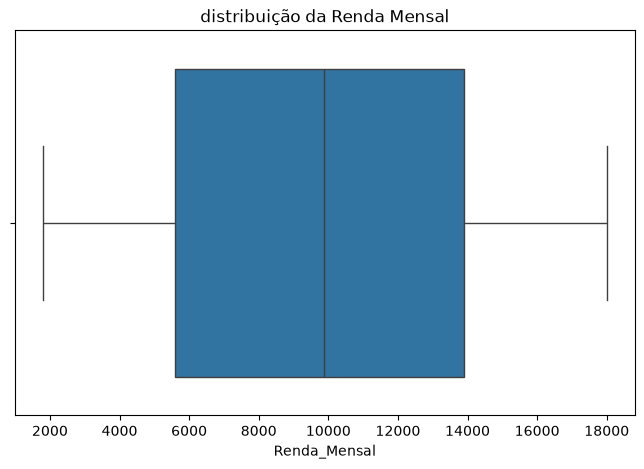

In [15]:
#distribuição renda mensal
plt.figure(figsize=(8,5))
sns.boxplot(x=tabela["Renda_Mensal"])

plt.title("distribuição da Renda Mensal")
plt.show()

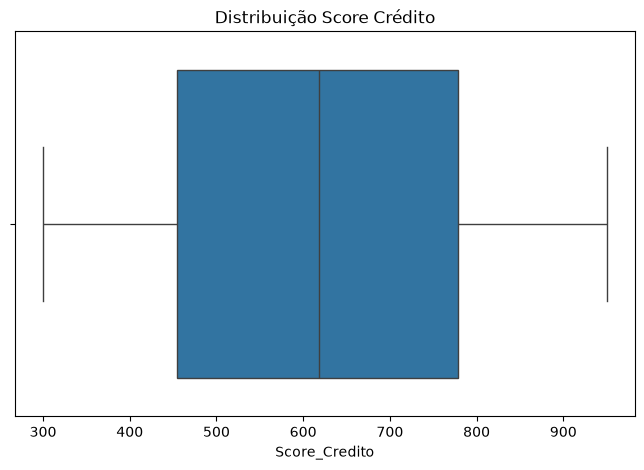

In [16]:
#distribuição Score Crédito
plt.figure(figsize=(8,5))
sns.boxplot(x=tabela["Score_Credito"])

plt.title("Distribuição Score Crédito")
plt.show()

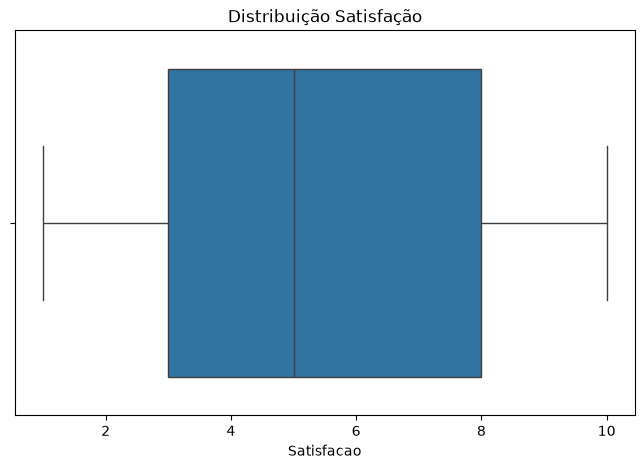

In [17]:
#distribuição satisfação
plt.figure(figsize=(8,5))
sns.boxplot(x=tabela["Satisfacao"])

plt.title("Distribuição Satisfação")
plt.show()

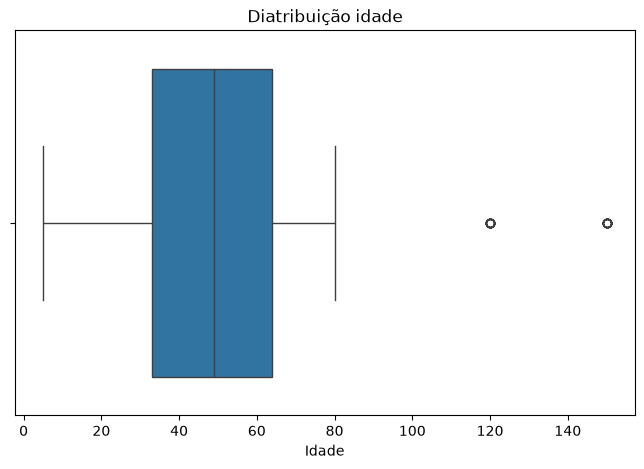

In [18]:
#Distribuição idade
plt.figure(figsize=(8,5))
sns.boxplot(x=tabela["Idade"])

plt.title("Diatribuição idade")
plt.show()

In [19]:
tabela["Idade"].value_counts().sort_index()

Idade
5      15
18     84
19     47
20     54
21     66
       ..
78     53
79     65
80     42
120    17
150    16
Name: count, Length: 66, dtype: int64

In [20]:
#verificando valores duplicados
tabela.duplicated().sum()

np.int64(120)

In [21]:
tabela[tabela.duplicated(keep=False)].sort_values(by="Cliente_ID")

,Cliente_ID,Data_Contratacao,Idade,Genero,Estado_Civil,Profissao,Renda_Mensal,Score_Credito,Regiao,Corretor,Tipo_Seguro,Plano,Valor_Mensal,Sinistros,Atrasos_Pagamento,Usa_App,Satisfacao,Cancelou,Motivo_Cancelamento
5,6,28/09/2022,47,Feminino,Solteiro,Enfermeiro,10893.0,679.0,NORTE,Ana,Auto,Anual,469,3,5,sim,10.0,Não,NaN
4095,6,28/09/2022,47,Feminino,Solteiro,Enfermeiro,10893.0,679.0,NORTE,Ana,Auto,Anual,469,3,5,sim,10.0,Não,NaN
4073,17,2024-05-11,28,Fem,solteiro,Administrador,8685.0,755.0,sudeste,Daniela,Auto,Mensal,520,0,5,sim,1.0,Sim,Insatisfação
16,17,2024-05-11,28,Fem,solteiro,Administrador,8685.0,755.0,sudeste,Daniela,Auto,Mensal,520,0,5,sim,1.0,Sim,Insatisfação
41,42,18-May-2024,36,Fem,Casado,Autônomo,3903.0,769.0,Norte,Eduardo,Auto,Anual,297,3,2,Sim,6.0,Não,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4037,3914,10/09/2021,70,Masc,Solteiro,Professor,NaN,811.0,Centro-Oeste,Daniela,Auto,Mensal,422,0,5,Sim,9.0,Não,NaN
4089,3951,11/01/2022,74,Fem,Solteiro,Engenheiro,7904.0,760.0,NORTE,Daniela,Vida,Mensal,134,0,5,sim,10.0,Não,NaN
3950,3951,11/01/2022,74,Fem,Solteiro,Engenheiro,7904.0,760.0,NORTE,Daniela,Vida,Mensal,134,0,5,sim,10.0,Não,NaN
3984,3985,2026-05-10,20,Fem,Solteiro,Vendedor,12083.0,578.0,Sul,Eduardo,Auto,Mensal,549,5,2,nao,10.0,Não,NaN


In [22]:
#Verificando Categorias inconsistentes
colunas_categoricas = tabela.select_dtypes(include=["object", "string"]).columns
colunas_categoricas

Index(['Data_Contratacao', 'Genero', 'Estado_Civil', 'Profissao', 'Regiao',
       'Corretor', 'Tipo_Seguro', 'Plano', 'Valor_Mensal', 'Usa_App',
       'Cancelou', 'Motivo_Cancelamento'],
      dtype='str')

In [23]:
for coluna in colunas_categoricas:
    print(f"\n-----{coluna}-----")
    print(tabela[coluna].value_counts())

    


-----Data_Contratacao-----
Data_Contratacao
23-Jul-2022    6
2022-11-27     5
2024-06-27     5
22-Nov-2021    5
28/06/2023     5
              ..
12-Oct-2023    1
26/03/2025     1
2021-08-01     1
18/10/2022     1
04-Jan-2023    1
Name: count, Length: 2853, dtype: int64

-----Genero-----
Genero
Masculino    708
Masc         708
F            693
Fem          686
Feminino     672
M            653
Name: count, dtype: int64

-----Estado_Civil-----
Estado_Civil
Solteiro      1080
solteiro      1042
Casado        1023
Divorciado     975
Name: count, dtype: int64

-----Profissao-----
Profissao
Programador      436
Professor        434
Enfermeiro       433
Administrador    424
Vendedor         423
Analista         417
programador      404
Engenheiro       389
Autônomo         384
Motorista        376
Name: count, dtype: int64

-----Regiao-----
Regiao
NORTE           427
Sul             426
Centro-Oeste    425
Nordeste        424
Sul             417
SUDESTE         413
Sudeste         405
Nort

Limpeza dos dados


In [24]:
#excluido os valores duplicados
tabela = tabela.drop_duplicates()


In [25]:
tabela.duplicated().sum()

np.int64(0)

In [26]:
#Corrigindo tipos: Data_contratação
tabela["Data_Contratacao"].head(10)

0    30-Sep-2022
1     2024-05-26
2     30/03/2024
3    16-Apr-2023
4     22/02/2022
5     28/09/2022
6     2022-03-12
7     2025-08-29
8     2024-10-22
9     2025-01-31
Name: Data_Contratacao, dtype: str

In [27]:
tabela["Data_Contratacao"]= pd.to_datetime(tabela["Data_Contratacao"], format="mixed", dayfirst=True)
tabela["Data_Contratacao"]

0      2022-09-30
1      2024-05-26
2      2024-03-30
3      2023-04-16
4      2022-02-22
          ...    
3995   2025-03-26
3996   2021-01-08
3997   2023-03-20
3998   2022-10-18
3999   2023-01-04
Name: Data_Contratacao, Length: 4000, dtype: datetime64[us]

In [28]:
tabela["Data_Contratacao"].sample(10)

1684   2026-06-09
2660   2024-05-18
1053   2024-07-09
3052   2025-11-26
596    2022-12-23
2951   2022-08-18
910    2021-07-30
2639   2024-12-12
2967   2022-08-23
1039   2024-01-07
Name: Data_Contratacao, dtype: datetime64[us]

In [29]:
#Corrigindo tipo: Valor_Mensal
tabela["Valor_Mensal"].apply(type).value_counts()

Valor_Mensal
<class 'int'>    3672
<class 'str'>     328
Name: count, dtype: int64

In [30]:
tabela["Valor_Mensal"] = tabela["Valor_Mensal"].astype(str)


In [31]:
tabela["Valor_Mensal"] = tabela["Valor_Mensal"].str.replace("R$ " , "", regex=False)

In [32]:
tabela["Valor_Mensal"]

0       174,00
1          485
2          542
3           44
4           61
         ...  
3995       100
3996    175,00
3997        68
3998       485
3999       597
Name: Valor_Mensal, Length: 4000, dtype: str

In [33]:
tabela["Valor_Mensal"] = tabela["Valor_Mensal"].str.replace("." , "" , regex=False)


In [34]:
tabela["Valor_Mensal"]

0       174,00
1          485
2          542
3           44
4           61
         ...  
3995       100
3996    175,00
3997        68
3998       485
3999       597
Name: Valor_Mensal, Length: 4000, dtype: str

In [35]:
tabela["Valor_Mensal"] = tabela["Valor_Mensal"].str.replace("," , "." , regex=False)

In [36]:
tabela["Valor_Mensal"]

0       174.00
1          485
2          542
3           44
4           61
         ...  
3995       100
3996    175.00
3997        68
3998       485
3999       597
Name: Valor_Mensal, Length: 4000, dtype: str

In [37]:
tabela["Valor_Mensal"] = pd.to_numeric(tabela["Valor_Mensal"], errors="coerce")

In [38]:
tabela["Valor_Mensal"]

0       174.0
1       485.0
2       542.0
3        44.0
4        61.0
        ...  
3995    100.0
3996    175.0
3997     68.0
3998    485.0
3999    597.0
Name: Valor_Mensal, Length: 4000, dtype: float64

In [39]:
# Corrigindo inconsistências nas categorias da coluna "Genero"
tabela["Genero"] = tabela["Genero"].str.title().str.strip()


In [40]:

correcao_genero ={
    "Masc":"Masculino",
    "M": "Masculino",
    "F": "Feminino",
    "Fem":"Feminino"
}

tabela["Genero"] = tabela["Genero"].replace(correcao_genero)

In [41]:
tabela["Genero"].value_counts()

Genero
Masculino    2010
Feminino     1990
Name: count, dtype: int64

In [42]:
# Corrigindo inconsistências nas categorias da coluna "Estado Civil"
tabela["Estado_Civil"] = tabela["Estado_Civil"].str.title().str.strip()

In [43]:
tabela["Estado_Civil"].value_counts()

Estado_Civil
Solteiro      2052
Casado        1000
Divorciado     948
Name: count, dtype: int64

In [44]:
# Corrigindo inconsistências nas categorias da coluna "Profissão"
tabela["Profissao"] = tabela["Profissao"].str.title().str.strip()

In [45]:
tabela["Profissao"].value_counts()

Profissao
Programador      816
Enfermeiro       422
Professor        422
Administrador    409
Vendedor         408
Analista         403
Engenheiro       379
Autônomo         376
Motorista        365
Name: count, dtype: int64

In [46]:
# Corrigindo inconsistências nas categorias da coluna "Regiao"
tabela["Regiao"]= tabela["Regiao"].str.title().str.strip()

In [47]:
tabela["Regiao"].value_counts()

Regiao
Sudeste         1562
Sul              820
Norte            795
Centro-Oeste     412
Nordeste         411
Name: count, dtype: int64

In [48]:
# Corrigindo inconsistências nas categorias da coluna "Usa_App"
tabela["Usa_App"] = tabela["Usa_App"].str.strip().str.title()

In [49]:
tabela["Usa_App"] = tabela["Usa_App"].replace("Nao" , "Não")

In [50]:
tabela["Usa_App"].value_counts()

Usa_App
Sim    2023
Não    1977
Name: count, dtype: int64

In [51]:
#Tratamento Valores nulos


# Preenchendo os valores nulos da coluna "Score_Credito" com a média
tabela["Score_Credito"] = tabela["Score_Credito"].fillna(tabela["Score_Credito"].mean())

# Preenchendo os valores nulos da coluna "Renda_Mensal" com a média
tabela["Renda_Mensal"] = tabela["Renda_Mensal"].fillna(tabela["Renda_Mensal"].mean())

In [52]:
tabela.isna().sum()

Cliente_ID                0
Data_Contratacao          0
Idade                     0
Genero                    0
Estado_Civil              0
Profissao                 0
Renda_Mensal              0
Score_Credito             0
Regiao                    0
Corretor                  0
Tipo_Seguro               0
Plano                     0
Valor_Mensal              0
Sinistros                 0
Atrasos_Pagamento         0
Usa_App                   0
Satisfacao              247
Cancelou                  0
Motivo_Cancelamento    2959
dtype: int64

In [53]:
tabela[tabela["Idade"] > 100]["Idade"].value_counts()

Idade
120    17
150    14
Name: count, dtype: int64

In [54]:
# Removendo registros com idade acima de 100 anos
tabela = tabela[tabela["Idade"]<=100]

In [55]:
tabela["Idade"].max()

np.int64(80)

## Análise Exploratória dos Dados (EDA)

In [56]:
tabela

,Cliente_ID,Data_Contratacao,Idade,Genero,Estado_Civil,Profissao,Renda_Mensal,Score_Credito,Regiao,Corretor,Tipo_Seguro,Plano,Valor_Mensal,Sinistros,Atrasos_Pagamento,Usa_App,Satisfacao,Cancelou,Motivo_Cancelamento
0,1,2022-09-30,75,Masculino,Divorciado,Programador,9249.0,617.000000,Nordeste,Eduardo,Residencial,Anual,174.0,3,4,Não,6.0,Não,NaN
1,2,2024-05-26,53,Feminino,Casado,Enfermeiro,12861.0,749.000000,Sudeste,Bruno,Auto,Mensal,485.0,1,6,Não,10.0,Não,NaN
2,3,2024-03-30,63,Feminino,Divorciado,Vendedor,10388.0,940.000000,Centro-Oeste,Bruno,Auto,Mensal,542.0,4,3,Sim,5.0,Sim,Preço
3,4,2023-04-16,35,Masculino,Solteiro,Vendedor,15863.0,455.000000,Sudeste,Daniela,Residencial,Mensal,44.0,3,2,Sim,10.0,Não,NaN
4,5,2022-02-22,28,Masculino,Solteiro,Engenheiro,6487.0,885.000000,Centro-Oeste,Bruno,Residencial,Anual,61.0,3,2,Sim,8.0,Não,Preço
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,2025-03-26,72,Feminino,Solteiro,Programador,14521.0,619.094902,Sul,Carlos,Residencial,Mensal,100.0,5,1,Sim,9.0,Não,NaN
3996,3997,2021-01-08,53,Feminino,Divorciado,Programador,4357.0,643.000000,Nordeste,Eduardo,Vida,Anual,175.0,3,6,Sim,3.0,Não,NaN
3997,3998,2023-03-20,46,Feminino,Solteiro,Motorista,5039.0,538.000000,Norte,Bruno,Residencial,Anual,68.0,5,1,Sim,1.0,Não,NaN
3998,3999,2022-10-18,50,Feminino,Solteiro,Engenheiro,2556.0,428.000000,Nordeste,Eduardo,Saúde,Anual,485.0,4,4,Sim,10.0,Não,NaN


### Análise 1 - Quais são os principais motivos de cancelamento?



In [57]:
#Quantidade de cancelamento por motivo
motivo_cancelamento = tabela["Motivo_Cancelamento"].value_counts().sort_values(ascending=False).reset_index(name="quantidade")
motivo_cancelamento


,Motivo_Cancelamento,quantidade
0,Preço,279
1,Mudança de cidade,196
2,Concorrência,191
3,Mudança financeira,190
4,Insatisfação,172


In [58]:
#Filtrando clientes que cancelaram por preço
cancelamento_preco = tabela[tabela["Motivo_Cancelamento"] == "Preço"]
cancelamento_preco

,Cliente_ID,Data_Contratacao,Idade,Genero,Estado_Civil,Profissao,Renda_Mensal,Score_Credito,Regiao,Corretor,Tipo_Seguro,Plano,Valor_Mensal,Sinistros,Atrasos_Pagamento,Usa_App,Satisfacao,Cancelou,Motivo_Cancelamento
2,3,2024-03-30,63,Feminino,Divorciado,Vendedor,10388.0,940.0,Centro-Oeste,Bruno,Auto,Mensal,542.0,4,3,Sim,5.0,Sim,Preço
4,5,2022-02-22,28,Masculino,Solteiro,Engenheiro,6487.0,885.0,Centro-Oeste,Bruno,Residencial,Anual,61.0,3,2,Sim,8.0,Não,Preço
14,15,2022-12-02,42,Feminino,Divorciado,Engenheiro,11113.0,651.0,Sudeste,Eduardo,Auto,Anual,206.0,4,0,Sim,3.0,Não,Preço
77,78,2025-02-23,60,Feminino,Casado,Enfermeiro,17652.0,890.0,Sudeste,Fernanda,Vida,Mensal,122.0,1,2,Não,7.0,Sim,Preço
88,89,2022-04-25,62,Feminino,Solteiro,Analista,6278.0,762.0,Centro-Oeste,Ana,Saúde,Anual,514.0,0,4,Sim,8.0,Não,Preço
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,3909,2021-11-18,22,Feminino,Divorciado,Autônomo,13839.0,341.0,Nordeste,Carlos,Auto,Mensal,232.0,0,2,Não,9.0,Sim,Preço
3924,3925,2021-11-23,30,Masculino,Solteiro,Analista,16005.0,383.0,Norte,Ana,Auto,Mensal,501.0,2,4,Não,1.0,Não,Preço
3929,3930,2023-06-30,61,Masculino,Divorciado,Enfermeiro,3240.0,622.0,Nordeste,Daniela,Saúde,Anual,741.0,3,5,Sim,9.0,Sim,Preço
3934,3935,2022-02-19,70,Masculino,Divorciado,Administrador,4515.0,591.0,Sul,Eduardo,Vida,Mensal,125.0,5,6,Sim,7.0,Não,Preço


In [59]:
#Visualizando informações
cancelamento_preco[["Cliente_ID", "Valor_Mensal", "Motivo_Cancelamento"]]

,Cliente_ID,Valor_Mensal,Motivo_Cancelamento
2,3,542.0,Preço
4,5,61.0,Preço
14,15,206.0,Preço
77,78,122.0,Preço
88,89,514.0,Preço
...,...,...,...
3908,3909,232.0,Preço
3924,3925,501.0,Preço
3929,3930,741.0,Preço
3934,3935,125.0,Preço


In [60]:
cancelamento_preco["Valor_Mensal"].describe()

count     279.000000
mean      386.437276
std       286.727872
min        30.000000
25%       149.000000
50%       299.000000
75%       558.500000
max      1169.000000
Name: Valor_Mensal, dtype: float64

In [61]:
#Tipo de seguro desses clientes
cancelamento_preco["Tipo_Seguro"].value_counts()

Tipo_Seguro
Auto           92
Saúde          88
Vida           53
Residencial    46
Name: count, dtype: int64

In [62]:
tabela.groupby("Motivo_Cancelamento")["Valor_Mensal"].mean()

Motivo_Cancelamento
Concorrência          380.256545
Insatisfação          398.354651
Mudança de cidade     377.147959
Mudança financeira    409.500000
Preço                 386.437276
Name: Valor_Mensal, dtype: float64

### Insight

O principal motivo de cancelamento identificado foi o preço. 
Entre os clientes que cancelaram por esse motivo, o seguro Auto apresentou a maior quantidade de cancelamentos.

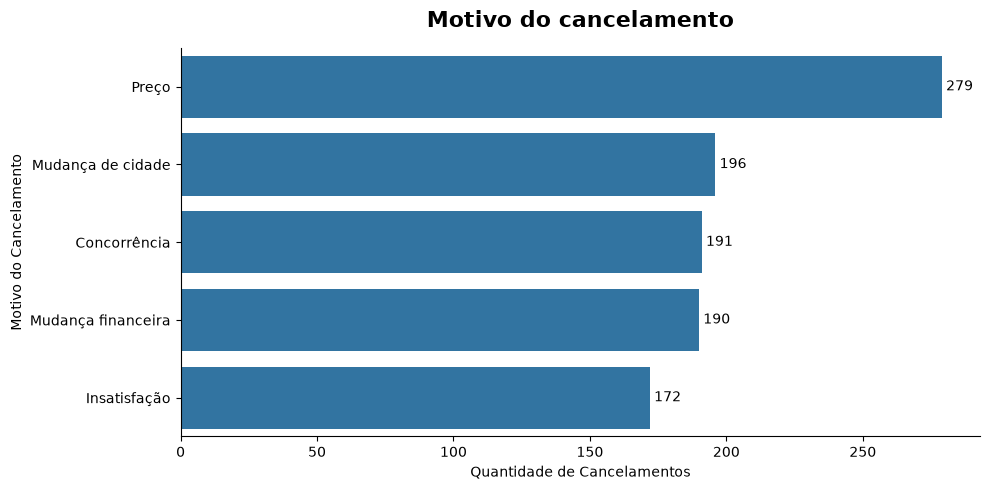

In [63]:
plt.figure(figsize=(10,5))
ax= sns.barplot(
    data=motivo_cancelamento,
    y="Motivo_Cancelamento",
    x="quantidade"
)

ax.bar_label(
    ax.containers[0],
    padding= 3,
    fontsize=10
    )

plt.title(
    "Motivo do cancelamento",
    fontsize= 16,
    weight= 'bold',
    pad=15
    )

plt.xlabel("Quantidade de Cancelamentos")
plt.ylabel("Motivo do Cancelamento")

sns.despine()
plt.tight_layout()
plt.show()


### Análise 2 - Qual corretor realizou o maior número de vendas?

In [64]:
tabela

,Cliente_ID,Data_Contratacao,Idade,Genero,Estado_Civil,Profissao,Renda_Mensal,Score_Credito,Regiao,Corretor,Tipo_Seguro,Plano,Valor_Mensal,Sinistros,Atrasos_Pagamento,Usa_App,Satisfacao,Cancelou,Motivo_Cancelamento
0,1,2022-09-30,75,Masculino,Divorciado,Programador,9249.0,617.000000,Nordeste,Eduardo,Residencial,Anual,174.0,3,4,Não,6.0,Não,NaN
1,2,2024-05-26,53,Feminino,Casado,Enfermeiro,12861.0,749.000000,Sudeste,Bruno,Auto,Mensal,485.0,1,6,Não,10.0,Não,NaN
2,3,2024-03-30,63,Feminino,Divorciado,Vendedor,10388.0,940.000000,Centro-Oeste,Bruno,Auto,Mensal,542.0,4,3,Sim,5.0,Sim,Preço
3,4,2023-04-16,35,Masculino,Solteiro,Vendedor,15863.0,455.000000,Sudeste,Daniela,Residencial,Mensal,44.0,3,2,Sim,10.0,Não,NaN
4,5,2022-02-22,28,Masculino,Solteiro,Engenheiro,6487.0,885.000000,Centro-Oeste,Bruno,Residencial,Anual,61.0,3,2,Sim,8.0,Não,Preço
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,2025-03-26,72,Feminino,Solteiro,Programador,14521.0,619.094902,Sul,Carlos,Residencial,Mensal,100.0,5,1,Sim,9.0,Não,NaN
3996,3997,2021-01-08,53,Feminino,Divorciado,Programador,4357.0,643.000000,Nordeste,Eduardo,Vida,Anual,175.0,3,6,Sim,3.0,Não,NaN
3997,3998,2023-03-20,46,Feminino,Solteiro,Motorista,5039.0,538.000000,Norte,Bruno,Residencial,Anual,68.0,5,1,Sim,1.0,Não,NaN
3998,3999,2022-10-18,50,Feminino,Solteiro,Engenheiro,2556.0,428.000000,Nordeste,Eduardo,Saúde,Anual,485.0,4,4,Sim,10.0,Não,NaN


In [65]:
tabela["Corretor"].value_counts().sort_values(ascending=False).reset_index(name="Total")

,Corretor,Total
0,Fernanda,679
1,Eduardo,667
2,Daniela,663
3,Carlos,658
4,Bruno,657
5,Ana,645


### Insight:

A corretora Fernanda foi a que realizou o maior número de vendas na base de dados.

### Análise 3 - Qual tipo de seguro foi mais vendido pela corretora Fernanda?

In [66]:
corretor_fernanda = tabela[tabela["Corretor"] == "Fernanda"]

In [67]:
corretor_fernanda["Tipo_Seguro"].value_counts()

Tipo_Seguro
Auto           242
Saúde          192
Residencial    124
Vida           121
Name: count, dtype: int64

### Insight:
 Entre as vendas da corretora Fernanda, o seguro Auto foi o mais comercializado.

### Análise 4 - Qual tipo de seguro foi mais vendido no geral?

In [68]:
tabela["Tipo_Seguro"].value_counts().reset_index()

,Tipo_Seguro,count
0,Auto,1388
1,Saúde,1188
2,Vida,777
3,Residencial,616


### insight:
O seguro auto é o mais vendido

## Análise 5 - Qual o percentual de clientes que usam o App?

In [69]:
tabela["Usa_App"].value_counts(normalize=True).mul(100).round(2).reset_index(name="%")

,Usa_App,%
0,Sim,50.64
1,Não,49.36


### insight: 
50.64% utilizam aplicativo, enquanto 49.36% não utilizam

## Análise 6 - Clientes que usam app cancelam menos ?

In [70]:
cancelar_app = tabela.groupby("Usa_App")["Cancelou"].value_counts(normalize=True).mul(100).round(2).reset_index(name="%")
cancelar_app

,Usa_App,Cancelou,%
0,Não,Não,75.65
1,Não,Sim,24.35
2,Sim,Não,76.62
3,Sim,Sim,23.38


In [71]:
taxa_cancelamento_app = cancelar_app [cancelar_app["Cancelou"] == "Sim"]
taxa_cancelamento_app

,Usa_App,Cancelou,%
1,Não,Sim,24.35
3,Sim,Sim,23.38


## Insight:

A diferença na taxa de cancelamento entre clientes que utilizam e não utilizam o aplicativo foi pequena. Clientes que utilizam o app apresentaram uma taxa de cancelamento ligeiramente menor (23,38%) em comparação aos clientes que não utilizam (24,35%). o uso do aplicativo não apresentou uma diferença significativa na retenção dos clientes.

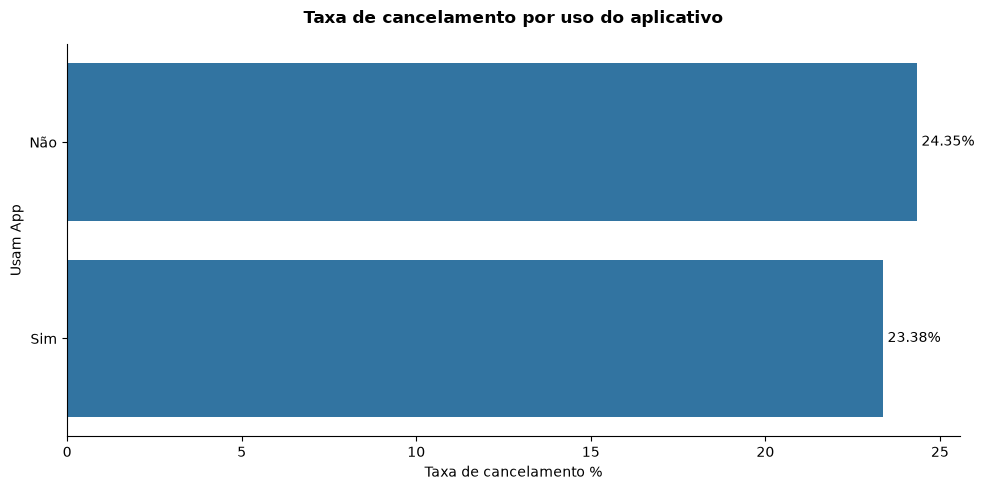

In [72]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=taxa_cancelamento_app,
    y="Usa_App",
    x="%"
)

ax.bar_label(
    ax.containers[0],
    padding=3,
    fontsize=10,
    fmt="%.2f%%"
)

plt.title(
    "Taxa de cancelamento por uso do aplicativo",
    fontsize=12,
    weight='bold',
    pad=15
)

plt.ylabel("Usam App")
plt.xlabel("Taxa de cancelamento %")

sns.despine()
plt.tight_layout()
plt.show()

## Análise 7 - A satisfação do cliente influencia o cancelamento?

In [73]:
satisfacao_cancelamento = tabela.groupby("Satisfacao")["Cancelou"].value_counts(normalize=True).mul(100).round(2).reset_index(name="%")
satisfacao_cancelamento

,Satisfacao,Cancelou,%
0,1.0,Não,70.36
1,1.0,Sim,29.64
2,2.0,Não,71.12
3,2.0,Sim,28.88
4,3.0,Não,74.63
5,3.0,Sim,25.37
6,4.0,Não,75.18
7,4.0,Sim,24.82
8,5.0,Não,78.53
9,5.0,Sim,21.47


In [74]:
taxa_cancelamento = satisfacao_cancelamento[satisfacao_cancelamento["Cancelou"] == "Sim"]
taxa_cancelamento

,Satisfacao,Cancelou,%
1,1.0,Sim,29.64
3,2.0,Sim,28.88
5,3.0,Sim,25.37
7,4.0,Sim,24.82
9,5.0,Sim,21.47
11,6.0,Sim,24.15
13,7.0,Sim,21.18
15,8.0,Sim,21.32
17,9.0,Sim,26.24
19,10.0,Sim,16.43


## Insight:

De forma geral, clientes com níveis mais altos de satisfação apresentam menores taxas de cancelamento. No entanto, essa relação não é linear, pois existem oscilações ao longo das notas, com destaque para o aumento da taxa de cancelamento entre clientes com satisfação 9.

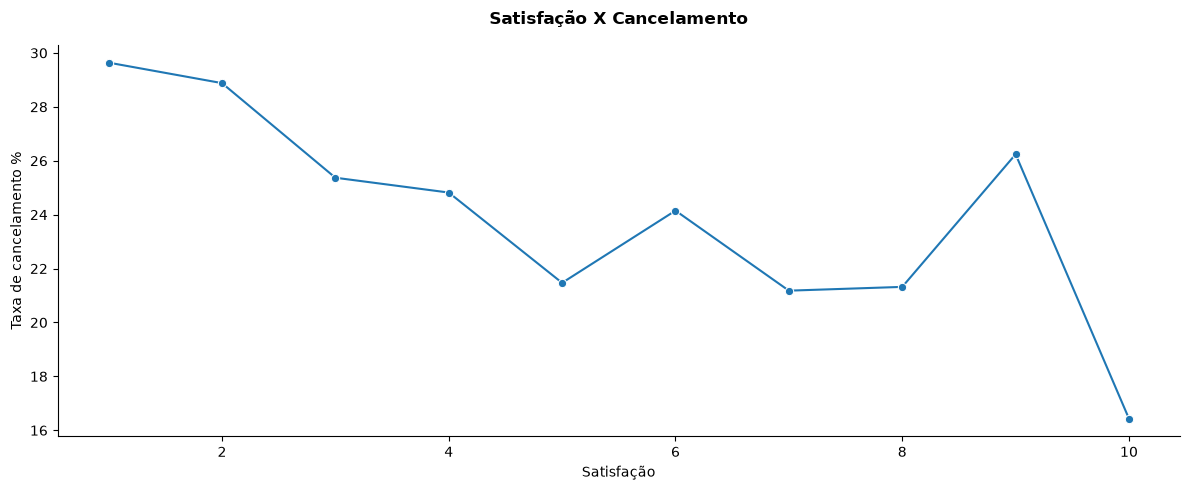

In [75]:
plt.figure(figsize=(12,5))

ax = sns.lineplot(
    taxa_cancelamento ,
    x="Satisfacao",
    y="%",
    marker= "o"
    
)

plt.title(
    "Satisfação X Cancelamento",
    fontsize=12,
    weight='bold',
    pad=15
)

plt.xlabel("Satisfação")
plt.ylabel("Taxa de cancelamento %")

sns.despine()
plt.tight_layout()
plt.show()

### Análise 8 - Por que clientes com satisfação 9 apresentam uma taxa de cancelamento relativamente alta?

In [76]:
satisfacao_9= tabela[tabela["Satisfacao"] == 9]
satisfacao9_cancelou = satisfacao_9[satisfacao_9["Cancelou"] == "Sim"]

In [77]:
satisfacao9_cancelou["Motivo_Cancelamento"].value_counts()

Motivo_Cancelamento
Concorrência          25
Insatisfação          20
Preço                 19
Mudança de cidade     17
Mudança financeira     9
Name: count, dtype: int64

## Insight:
Entre os clientes com satisfação 9 que cancelaram, o principal motivo foi Concorrência, com 25 casos. Também foram identificados 20 cancelamentos por Insatisfação, o que chama atenção por se tratar de clientes com alta nota de satisfação. Como a base não informa quando a satisfação foi medida nem detalha o motivo do cancelamento, não é possível determinar a causa dessa aparente inconsistência.

### Análise 9 - Qual tipo de seguro possui maior taxa de cancelamento?

In [78]:
tipo_seguro = tabela.groupby("Tipo_Seguro")["Cancelou"].value_counts(normalize=True).mul(100).round(2).reset_index(name="%")
tipo_seguro

,Tipo_Seguro,Cancelou,%
0,Auto,Não,77.02
1,Auto,Sim,22.98
2,Residencial,Não,76.14
3,Residencial,Sim,23.86
4,Saúde,Não,75.59
5,Saúde,Sim,24.41
6,Vida,Não,75.42
7,Vida,Sim,24.58


In [79]:
taxa_tipo_seguro = tipo_seguro[tipo_seguro["Cancelou"] == "Sim"]
taxa_tipo_seguro

,Tipo_Seguro,Cancelou,%
1,Auto,Sim,22.98
3,Residencial,Sim,23.86
5,Saúde,Sim,24.41
7,Vida,Sim,24.58


## Insight:

O Seguro vida apresentou a maior taxa de cancelamento com 24.58%, Seguindo pelo Seguro saúde com 24.41%. No entanto as taxas foram relativamento próximas entre todos os tipos de seguro, não indicando uma concentração expressiva de cancelamentos em um único produto.

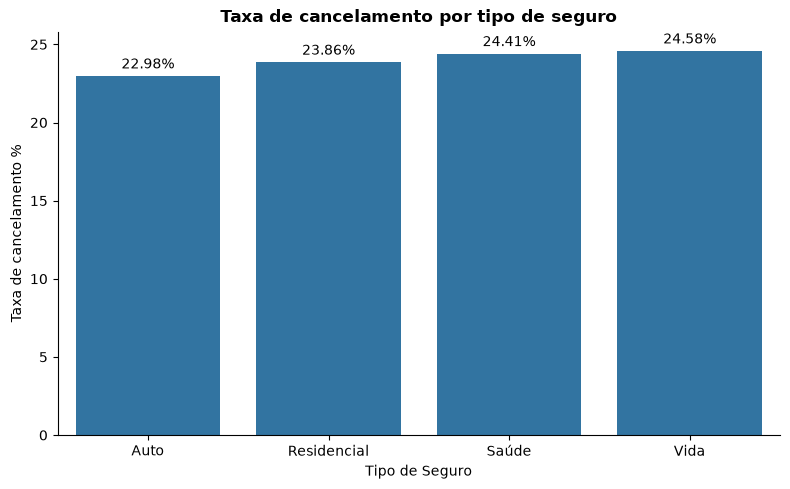

In [80]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=taxa_tipo_seguro,
    x="Tipo_Seguro",
    y="%"
)

ax.bar_label(
    ax.containers[0],
    padding=3,
    fmt="%.2f%%"
)

plt.title(
    "Taxa de cancelamento por tipo de seguro",
    fontsize=12,
    weight='bold',
    pad=7
)


plt.xlabel("Tipo de Seguro")
plt.ylabel("Taxa de cancelamento %")

sns.despine()
plt.tight_layout()
plt.show()

### Análise 10- Clientes com maior score de crédito cancelam menos?

In [81]:
tabela["Faixa_Score"]= pd.cut(tabela["Score_Credito"], bins=[300, 500, 700, 850, 1000], labels=["Baixo", "Médio", "Alto", "Muito alto"], right=False)

In [82]:
tabela["Faixa_Score"]

0            Médio
1             Alto
2       Muito alto
3            Baixo
4       Muito alto
           ...    
3995         Médio
3996         Médio
3997         Médio
3998         Baixo
3999    Muito alto
Name: Faixa_Score, Length: 3969, dtype: category
Categories (4, str): ['Baixo' < 'Médio' < 'Alto' < 'Muito alto']

In [83]:
faixa_score = tabela.groupby("Faixa_Score")["Cancelou"].value_counts(normalize=True).mul(100).round(2).reset_index(name="%")
faixa_score

,Faixa_Score,Cancelou,%
0,Baixo,Não,74.94
1,Baixo,Sim,25.06
2,Médio,Não,79.04
3,Médio,Sim,20.96
4,Alto,Não,74.15
5,Alto,Sim,25.85
6,Muito alto,Não,74.87
7,Muito alto,Sim,25.13


In [84]:
taxa_faixa_score = faixa_score[faixa_score["Cancelou"] == "Sim"]
taxa_faixa_score

,Faixa_Score,Cancelou,%
1,Baixo,Sim,25.06
3,Médio,Sim,20.96
5,Alto,Sim,25.85
7,Muito alto,Sim,25.13


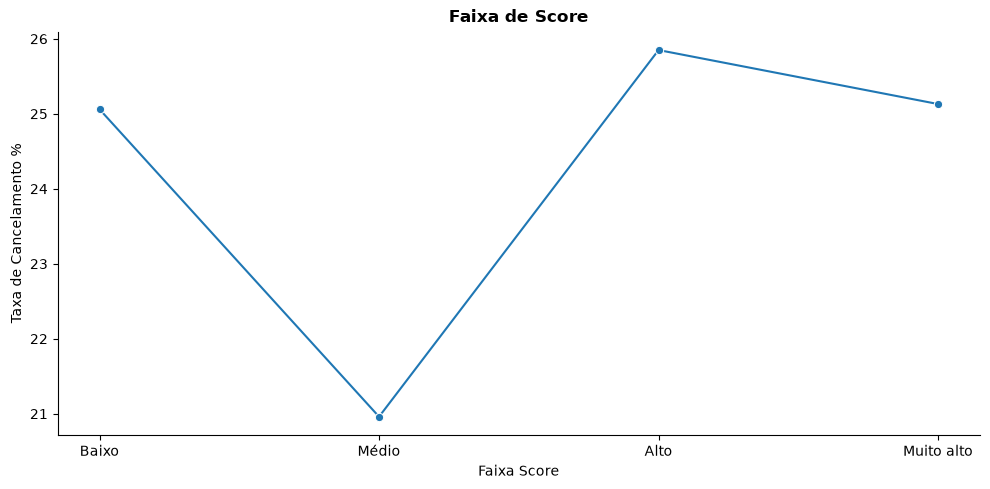

In [85]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(
    data=taxa_faixa_score,
    y="%",
    x="Faixa_Score",
    marker= "o"

)


plt.title(
    "Faixa de Score",
    fontsize=12,
    weight='bold',
    pad=7
)

plt.xlabel("Faixa Score")
plt.ylabel("Taxa de Cancelamento %")

sns.despine()
plt.tight_layout()
plt.show()

## Insight:

Os dados indicam que clientes com maior score de crédito não necessariamente apresentam menor taxa de cancelamento. As taxas permaneceram relativamente próximas entre as faixas, sem uma tendência consistente de redução conforme o score aumenta.

### Conclusão

O preço foi identificado como o principal motivo de cancelamento. Diante disso, recomenda-se avaliar estratégias direcionadas aos clientes mais sensíveis a preço, como ofertas personalizadas, revisão de planos ou benefícios adicionais. Também seria interessante investigar a percepção de custo-benefício dos clientes, já que uma possível hipótese é que parte deles não considere os benefícios oferecidos suficientes em relação ao valor pago.

Em relação ao uso do aplicativo, a diferença entre as taxas de cancelamento dos clientes que utilizam e dos que não utilizam o app foi pequena. Portanto, não há evidências suficientes, nesta análise, para priorizar investimentos no aplicativo como estratégia de redução de cancelamentos.

Embora o seguro Vida apresente a maior taxa de cancelamento (24,58%), as taxas entre os diferentes tipos de seguro são próximas. Portanto, não há evidência suficiente para concentrar a estratégia de retenção exclusivamente nesse tipo de seguro. As ações de retenção devem considerar outros fatores além do produto contratado.

Em relação à satisfação, foi observada uma tendência geral de menores taxas de cancelamento em alguns níveis mais altos de satisfação. No entanto, existem oscilações relevantes entre as notas. Dessa forma, seria necessário aprofundar a investigação antes de concluir que o aumento da satisfação, isoladamente, levaria à redução dos cancelamentos.

O score de crédito não apresentou uma relação clara com o cancelamento, pois as taxas permaneceram relativamente próximas entre as diferentes faixas de score, sem uma tendência consistente de redução conforme o score aumenta.

## Limitações da análise

Este projeto utiliza um conjunto de dados sintético desenvolvido para fins educacionais. Por esse motivo, os padrões e relações encontrados durante a análise não devem ser interpretados como representativos do comportamento de clientes de uma seguradora real. Além disso, algumas variáveis apresentaram relações que exigiriam maior contexto para serem interpretadas adequadamente.

As recomendações apresentadas devem ser entendidas como hipóteses de negócio baseadas nos dados disponíveis e não como conclusões causais.